# Cow Detection + Behavior Classification Pipeline

**Objective**: Combine YOLO detection with ViT classification for end-to-end cow behavior analysis on raw video frames.

**Dataset**: 25K labeled cow crops across 5 behaviors (drinking, foraging, lying, rumination, standing)

**Models**: 
- YOLO cow detector (trained on bounding box annotations)
- ViT behavior classifier (92.6% accuracy on crops)

**Pipeline**: Raw Frame → Detection → Crop Extraction → Classification → Annotated Results

In [1]:
# Core Python & data handling
import cv2
import numpy as np
from pathlib import Path
import subprocess

# ML libraries  
import torch
import torch.nn.functional as F
from ultralytics import YOLO
from transformers import AutoImageProcessor, AutoModelForImageClassification
from PIL import Image

# Visualization
import matplotlib.pyplot as plt
from IPython.display import Video, display

# Set device and seed
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using:", torch.cuda.get_device_name())
torch.manual_seed(42)

Using: NVIDIA GeForce RTX 4080


In [2]:
# Configuration
YOLO_MODEL_PATH = "runs/detect/train3/weights/best.pt"
VIT_MODEL_PATH = "models/cow-behavior-vit"
DETECTION_CONF = 0.25
IMG_SIZE = 640
SEED = 42

In [3]:
# Load models with validation
assert Path(YOLO_MODEL_PATH).exists(), f"YOLO model not found: {YOLO_MODEL_PATH}"
assert Path(VIT_MODEL_PATH).exists(), f"ViT model not found: {VIT_MODEL_PATH}"

detector = YOLO(YOLO_MODEL_PATH)
processor = AutoImageProcessor.from_pretrained(VIT_MODEL_PATH, use_fast=True)
classifier = AutoModelForImageClassification.from_pretrained(VIT_MODEL_PATH).to(device)
classifier.eval()

# Get class mappings
id2label = classifier.config.id2label
class_names = list(id2label.values())
print(f"Loaded models. Classes: {class_names}")

# Quick validation test
test_crop = torch.randn(1, 3, 224, 224).to(device)
with torch.no_grad():
    _ = classifier(test_crop)
print("✓ Pipeline ready")

Loaded models. Classes: ['drinking water', 'foraging', 'lying down', 'rumination', 'stand']
✓ Pipeline ready


In [4]:
# Core pipeline functions
def detect_cows(image_path):
    # Run YOLO detection
    results = detector.predict(source=image_path, conf=DETECTION_CONF, verbose=False)[0]
    if len(results.boxes) == 0:
        return []
    boxes = results.boxes.xyxy.cpu().numpy().astype(int).tolist()
    return boxes

def classify_behavior(crop):
    # Classify cow behavior from image crop
    crop_rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
    inputs = processor(Image.fromarray(crop_rgb), return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}
    
    with torch.no_grad():
        logits = classifier(**inputs).logits
        probs = F.softmax(logits, dim=-1)
    
    pred_id = logits.argmax().item()
    return {"class": id2label[pred_id], "conf": probs[0][pred_id].item()}

def process_image(image_path):
    # Complete pipeline: detect + classify
    image = cv2.imread(str(image_path))
    boxes = detect_cows(image_path)
    
    results = []
    for box in boxes:
        x1, y1, x2, y2 = box
        crop = image[y1:y2, x1:x2]
        behavior = classify_behavior(crop)
        results.append({"bbox": box, "behavior": behavior["class"], "conf": behavior["conf"]})
    
    return results

def process_video(video_path, output_path, max_frames=30):
    # Process video frames with detection + classification using ffmpeg
    cap = cv2.VideoCapture(str(video_path))
    
    # Check if video opened successfully
    if not cap.isOpened():
        print(f"Error: Could not open video {video_path}")
        return {"frames": 0, "detections": 0, "fps": 0}
    
    fps = int(cap.get(cv2.CAP_PROP_FPS))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    
    # Setup ffmpeg command for video encoding
    ffmpeg_cmd = [
        'ffmpeg', '-y',  # -y to overwrite output file
        '-f', 'rawvideo',
        '-vcodec', 'rawvideo',
        '-s', f'{width}x{height}',
        '-pix_fmt', 'bgr24',
        '-r', str(fps),
        '-i', '-',  # Read from stdin
        '-c:v', 'libx264',
        '-pix_fmt', 'yuv420p',
        '-crf', '18',  # High quality
        str(output_path)
    ]
    
    try:
        # Start ffmpeg process
        ffmpeg_process = subprocess.Popen(ffmpeg_cmd, stdin=subprocess.PIPE, 
                                        stderr=subprocess.PIPE, stdout=subprocess.PIPE)
        
        total_detections, frame_count = 0, 0
        while cap.isOpened() and frame_count < max_frames:
            ret, frame = cap.read()
            if not ret:
                break
            
            # Detect and annotate frame
            boxes = detect_cows(frame)
            for box in boxes:
                x1, y1, x2, y2 = box
                crop = frame[y1:y2, x1:x2]
                if crop.size > 0:
                    behavior = classify_behavior(crop)
                    cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
                    label = f"{behavior['class']} ({behavior['conf']:.2f})"
                    cv2.putText(frame, label, (x1, y1-10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)
            
            # Write frame to ffmpeg stdin
            try:
                ffmpeg_process.stdin.write(frame.tobytes())
            except BrokenPipeError:
                print("FFmpeg process ended unexpectedly")
                break
            
            total_detections += len(boxes)
            frame_count += 1
        
        # Close ffmpeg stdin and wait for process to finish
        ffmpeg_process.stdin.close()
        ffmpeg_process.wait()
        
        cap.release()
        
        # Check if ffmpeg succeeded
        if ffmpeg_process.returncode == 0:
            print(f"Output video saved: {output_path}")
        else:
            stderr_output = ffmpeg_process.stderr.read().decode('utf-8')
            print(f"FFmpeg error: {stderr_output}")
            return {"frames": frame_count, "detections": total_detections, "fps": fps}
        
    except FileNotFoundError:
        print("Error: ffmpeg not found. Please install ffmpeg.")
        return {"frames": 0, "detections": 0, "fps": 0}
    except Exception as e:
        print(f"Error during video processing: {e}")
        cap.release()
        return {"frames": 0, "detections": 0, "fps": 0}
    
    return {"frames": frame_count, "detections": total_detections, "fps": fps}

In [5]:
# Visualization
def show_results(image_path, results=None):
    # Display image with detection results
    image = cv2.imread(str(image_path))
    if results is None:
        results = process_image(image_path)
    
    # Draw bounding boxes and labels
    for result in results:
        x1, y1, x2, y2 = result["bbox"]
        behavior = result["behavior"]
        conf = result["conf"]
        
        cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)
        label = f"{behavior} ({conf:.2f})"
        cv2.putText(image, label, (x1, y1-10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)
    
    plt.figure(figsize=(12, 8))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title(f"Detected {len(results)} cows")
    plt.show()
    
    return results

## Demo

Test the pipeline on sample validation images:

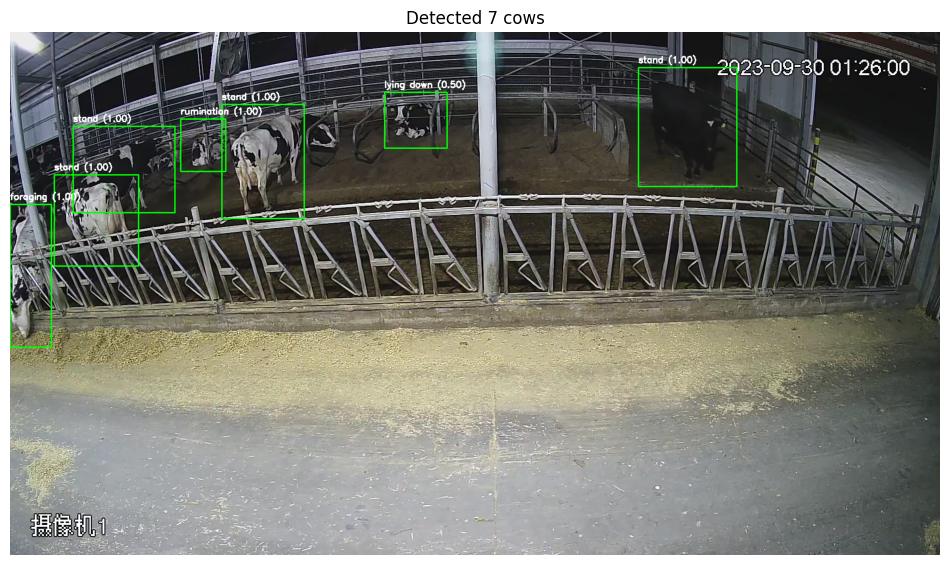

85_00007.jpg: 7 cows detected
  1. stand (0.998)
  2. stand (0.998)
  3. stand (0.999)
  4. lying down (0.502)
  5. foraging (0.998)
  6. rumination (0.998)
  7. stand (0.997)



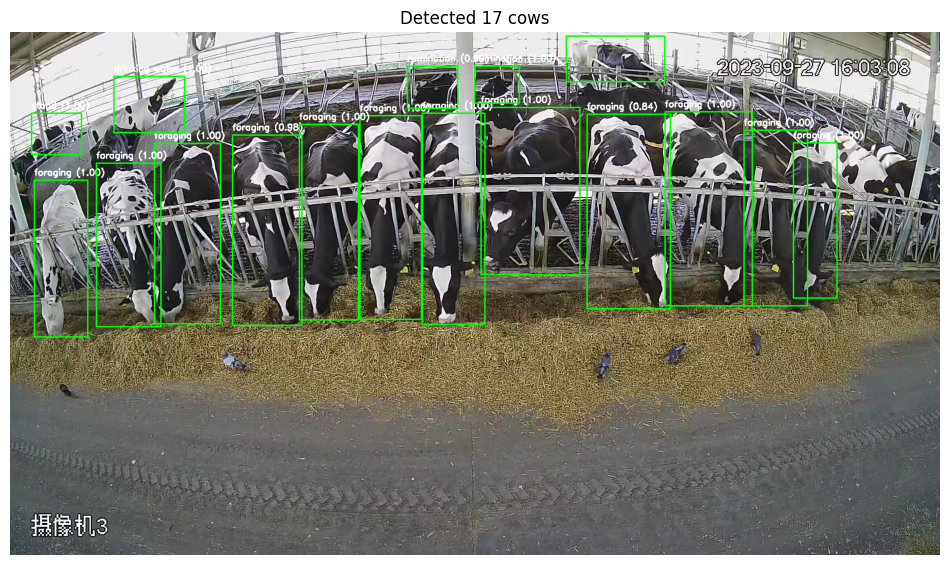

224_00005.jpg: 17 cows detected
  1. foraging (0.845)
  2. foraging (0.999)
  3. foraging (0.998)
  4. foraging (0.998)
  5. foraging (0.998)
  6. foraging (0.984)
  7. foraging (0.998)
  8. foraging (0.998)
  9. foraging (0.998)
  10. foraging (0.998)
  11. foraging (0.998)
  12. rumination (0.994)
  13. stand (0.999)
  14. foraging (0.998)
  15. stand (0.999)
  16. drinking water (0.995)
  17. rumination (0.997)



In [6]:
# Test on validation images
val_dir = Path("workdir/yolo_cow_oneclass/images/val")
if val_dir.exists():
    test_images = list(val_dir.glob("*.jpg"))[:2]
    if test_images:
        for img_path in test_images:
            results = show_results(str(img_path))
            print(f"{img_path.name}: {len(results)} cows detected")
            for i, r in enumerate(results, 1):
                print(f"  {i}. {r['behavior']} ({r['conf']:.3f})")
            print()
    else:
        print("No validation images found")
else:
    print(f"Directory not found: {val_dir}")
    print("Update path or test with: results = show_results('your_image.jpg')")

## Video Processing Demo

Process a complete video with frame-by-frame detection and classification:

In [8]:
# Random video processing demo
import random
import os

# Get random video from data/videos/videos/
video_dir = Path("data/videos/videos")
if video_dir.exists():
    video_files = list(video_dir.glob("*.mp4"))
    if video_files:
        # Select random video
        random_video = random.choice(video_files)
        print(f"Processing random video: {random_video.name}")
        
        # Create output directory if it doesn't exist
        output_dir = Path("output_videos")
        output_dir.mkdir(exist_ok=True)
        
        # Process video through pipeline - use .mp4 for notebook display
        output_path = output_dir / f"output_annotated_{random_video.stem}.mp4"
        stats = process_video(str(random_video), str(output_path), max_frames=50)
        
        print(f"\nProcessing Results:")
        print(f"Video: {random_video.name}")
        print(f"Frames processed: {stats['frames']}")
        print(f"Total detections: {stats['detections']}")
        print(f"FPS: {stats['fps']}")
        print(f"Annotated output: {output_path}")
        
        if stats['detections'] > 0:
            avg_detections = stats['detections'] / stats['frames']
            print(f"Avg detections/frame: {avg_detections:.2f}")
        else:
            print("No cows detected in this video")
        
        # Display the annotated video in notebook
        if output_path.exists():
            print(f"\nAnnotated Video:")
            display(Video(str(output_path), width=640, height=480))
        else:
            print("Video output not found for display")
    else:
        print("No video files found in data/videos/videos/")
else:
    print(f"Directory not found: {video_dir}")
    print("Please check the video directory path")

Processing random video: 357.mp4
Output video saved: output_videos/output_annotated_357.mp4

Processing Results:
Video: 357.mp4
Frames processed: 50
Total detections: 450
FPS: 25
Annotated output: output_videos/output_annotated_357.mp4
Avg detections/frame: 9.00

Annotated Video:
